In [93]:
# import stuff
import numpy as np, pickle, os
from ase.io import read
from ase.calculators.lammpslib import LAMMPSlib
from io import StringIO
from epicstuff import Bar

os.add_dll_directory(os.getenv('LOCALAPPDATA') + r'\LAMMPS 64-bit 2Aug2023-MSMPI with Python\bin')
None

In [2]:
# Variables
# "resolution"
res = 100
# repeat
repeat = 10, 10, 10
# cutoff = 2.5  # Cutoff distance for the potential
cutoff = 5

# Constants
# lattice parameters
a_from_to = 3.857, 3.844668
b_from_to = 3.857, 3.926152
c_from_to = 11.8194, 11.823664
# poscar
poscar = '''
Ba2 Y1 Cu3 O6 X1
1.0
   {a}    0.0    0.0
   0.0    {b}    0.0
   0.0    0.0   {c}
Ba Y Cu O X
2 1 3 6 1
direct
   0.5    0.5    0.819391 Ba2+
   0.5    0.5    0.180609 Ba2+
   0.5    0.5    0.500000 Y3+
   0.0    0.0    0.646678 Cu2+
   0.0    0.0    0.353322 Cu2+
   0.0    0.0    0.000000 Cu2+
   0.5    0.0    0.620653 O2-
   0.5    0.0    0.379347 O2-
   0.0    0.5    0.621651 O2-
   0.0    0.5    0.378349 O2-
   0.0    0.0    0.840820 O2-
   0.0    0.0    0.159180 O2-
   0.0    0.5    0.000000 X
'''.strip('\n')  # x is placeholder atom
# LAMMPS parameters, data from https://iopscience.iop.org/article/10.1088/1361-6668/ac47dc, Table 2
cmds = [  # Ba = 1, Y = 2, Cu = 3, O = 4.
	f'pair_style buck {cutoff}',
	'pair_coeff 1 1 1781.39 0.36 0.41',  # Ba-Ba
	'pair_coeff 2 2 1586.26 0.33 0.26',  # Y-Y
	'pair_coeff 3 3 4355.88 0.26 0.09',  # Cu-Cu
	'pair_coeff 1 2 1533.20 0.39 0.48',  # Ba-Y
	'pair_coeff 1 3 516.28 0.28 0.20',   # Ba-Cu
	'pair_coeff 2 3 2683.98 0.28 0.47',  # Y-Cu
	'pair_coeff 1 4 1814.69 0.32 0.41',  # Ba-O
	'pair_coeff 2 4 2113.25 0.28 2.84',  # Y-O
	'pair_coeff 3 4 2778.09 0.23 0.11',  # Cu-O
	'pair_coeff 4 4 2079.31 0.23 49.97'  # O-O
]
# total number of X atoms
num_x_tot = np.prod(repeat)

# Objects
# lattice parameter arrays
lattice_params = np.stack((np.linspace(*a_from_to, res), np.linspace(*b_from_to, res), np.linspace(*c_from_to, res)), axis=-1)
# extra oxygen percentage
oxy_perc = np.linspace(0, 1, res)

In [3]:

# array for the potential energies
pot_eng = np.zeros((res, res))
# loop though lattice parameters
with Bar() as bar:
	for i, (a, b, c) in enumerate(bar(lattice_params)):
		# loop though oxygen percentage
		for j, perc in enumerate(bar(oxy_perc, transient=True)):
			# load lattice
			atoms = read(StringIO(poscar.format(a=a, b=b, c=c)), format='vasp').repeat(repeat)
			# LAMMPS calculator, for some go forsaken reason, the calculator has to be redefined every time or memory access error, TODO: fix this
			atoms.calc = LAMMPSlib(lmpcmds=cmds)
			# calculations for oxygen replacement
			# number of X atoms to replace
			num_x_repl = round(num_x_tot * perc)
			# choose indices to replace
			indices = np.random.choice(range(num_x_tot), num_x_repl, replace=False)
			# replace, X is every 13th atom
			for index in indices:
				# make sure its correct atom
				assert atoms[index * 13 - 1].symbol == 'X'
				# replace with oxygen
				atoms[index * 13 - 1].symbol = 'O'
			# delete all other X atoms
			for index in range(num_x_tot, 0, -1):
				if index not in indices:
					# make sure its correct atom
					# assert atoms[index * 13 - 1].symbol == 'X', atoms[index * 13 - 1].symbol
					# TODO: replace the if back with the assert and fix why it not work
					if atoms[index * 13 - 1].symbol == 'X':
						del atoms[index * 13 - 1]
			# calculate potential energy
			pot_eng[i, j] = atoms.get_potential_energy() / len(atoms)
pickle.dump(pot_eng, open('pot_eng.pkl', 'wb'))			

Output()

In [90]:
import plotly.graph_objects as go
import numpy as np

fig = go.Figure(data=[
	go.Surface(z=pot_eng, x=lattice_params[:, 1], y=oxy_perc, colorscale='rainbow')
])
fig.update_layout(
	scene={'xaxis_title': 'Lattice Parameter (b value)', 'yaxis_title': 'Extra Oxygen Percentage', 'zaxis_title': 'Potential Energy'},
	margin={'l': 0, 'r': 0, 'b': 0, 't': 0},
	width=750,
	font={'family': 'times new roman', 'size': 12}
)
fig.show()

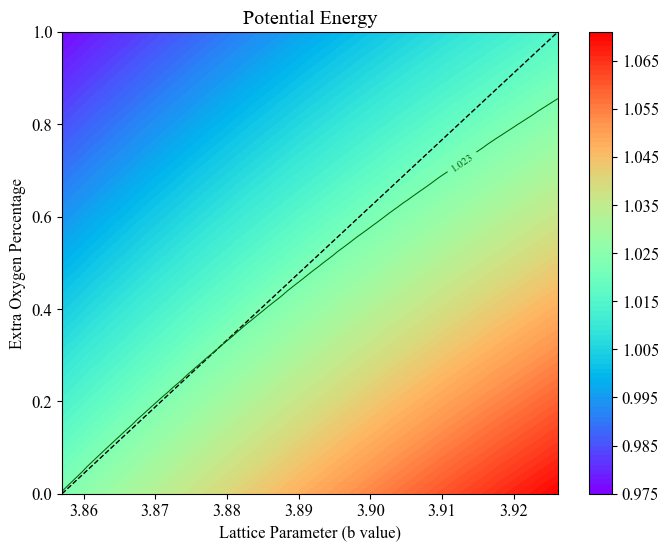

In [94]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Plot the contour plot
plt.figure(figsize=(8, 6))
plt.contourf(lattice_params[:, 1], oxy_perc, pot_eng, cmap='rainbow', levels=100)
plt.colorbar()#label='Potential Energy')

plt.plot([min(lattice_params[:, 1]), max(lattice_params[:, 1])], [min(oxy_perc), max(oxy_perc)], '--', color='black', linewidth=1)

specific_level = [1.023]  # replace 10 with the level you want to outline
contour = plt.contour(lattice_params[:, 1], oxy_perc, pot_eng, levels=specific_level, colors='darkgreen', linewidths=0.75)
plt.clabel(contour, inline=True, fontsize=8, manual=[(3.9, 1)])

plt.xlabel('Lattice Parameter (b value)')
plt.ylabel('Extra Oxygen Percentage')
plt.title('Potential Energy')
plt.show()

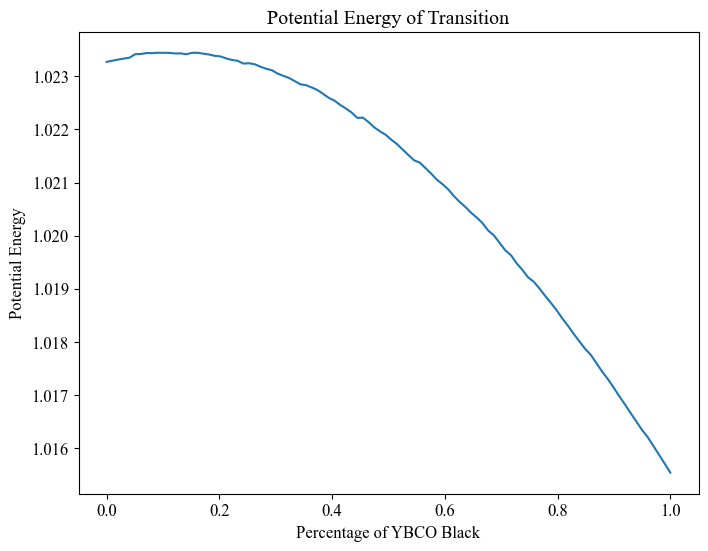

In [86]:
plt.figure(figsize=(8, 6))
plt.plot(oxy_perc, np.diag(pot_eng))
plt.xlabel('Percentage of YBCO Black')
plt.ylabel('Potential Energy')
plt.title('Potential Energy of Transition')
plt.show()